# Evalvaluate Predictions

In [1]:
%load_ext autoreload
%autoreload 2
import os
import polars as pl
import numpy as np
from deeptan.utils.metrics import MetricsDictMaker

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing metrics

In [2]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict", "deeptan")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")

### snRNA (balanced, extra test)

In [3]:
# dataset = "snrna_full_extra_nmic_g_mi02win001"
dataset = "snrna_full_extra_nmic_g_mi01win001"
path_true = os.path.join(path_raw_df, "snRNA", "ath_snrna_balanced_flower_seedling_rosette_split_full_extra")
path_orig_h5ad = os.path.join(path_true, "origin.h5ad")

metricsmaker = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true, True, path_orig_h5ad)
metricsmaker.load_predictions()
metricsmaker.load_true()


Found file📄 preds+seed_42+multitask+trn.h5 with task🎯 multitask and split🍰 trn.


In [4]:
# print(metricsmaker.fnames)

In [5]:
# g_embeddings = metricsmaker._read_batch_in_h5(metricsmaker.fnames[0], "g_embedding")
# print(g_embeddings.shape)

In [6]:
# obs_names_pred = metricsmaker._read_batch_in_h5(metricsmaker.fnames[0], "obs_name")
# obs_names_pred_list = [i.decode('utf-8') for i in obs_names_pred]
# print(len(obs_names_pred_list))
# print(obs_names_pred_list)

In [7]:
# print(len(metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]))
# print(metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"])

In [8]:
# if obs_names_pred_list == metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]:
#     print("list1 和 list2 的内容和顺序完全相同")
# else:
#     print("list1 和 list2 的内容和顺序不完全相同")

In [9]:
# if sorted(obs_names_pred_list) == sorted(metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]):
#     print("list1 和 list2 的内容和顺序完全相同")
# else:
#     print("list1 和 list2 的内容和顺序不完全相同")

### Write to CSV

In [10]:
# metricsmaker.metrics_dict["summary_recon"].write_csv(f"result.{dataset}.summary_recon.csv")
# metricsmaker.metrics_dict["summary_label"].write_csv(f"result.{dataset}.summary_label.csv")
# metricsmaker.metrics_dict["summary_clustering"].write_csv(f"result.{dataset}.summary_clustering.csv")

## Plot

In [4]:
from deeptan.utils.metrics import pacmap_plot, pacmap_plot_data

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

### Plot PaCMAP

In [5]:
_seed = 42
_split = "trn"
fig_name = f"fig.c2.snrna_balanced_extra.{_split}.cell_emb"

x_lab = "multitask"
x_lab_text = "Multitask"

y_labs = []
y_labs_text = []

_tasks = [x_lab] + y_labs
_tasks_text = [x_lab_text] + y_labs_text

In [6]:
true_features, pred_features, g_embs, y_true_text, ys_pred_text = pacmap_plot_data(metricsmaker, _tasks, _split, _seed)

Unique cell types:  ['Epidermal', 'Guard', 'Meristematic', 'Mesophyll', 'Stele', 'unknown']


In [7]:
print(true_features.shape)
print(g_embs["multitask"].shape)
print(pred_features["multitask"].shape)

(10005, 5431)
(10005, 512)
(10005, 5431)


In [8]:
# print(len(ys_pred_text["multitask"]))
# pl.DataFrame(ys_pred_text).write_parquet("predicted_labels_of_extra_test.parquet")
# print(len(y_true_text))
# pl.DataFrame({"multitask": y_true_text}).write_parquet("true_labels_of_extra_test.parquet")

#### Now we can plot

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)



Task: multitask


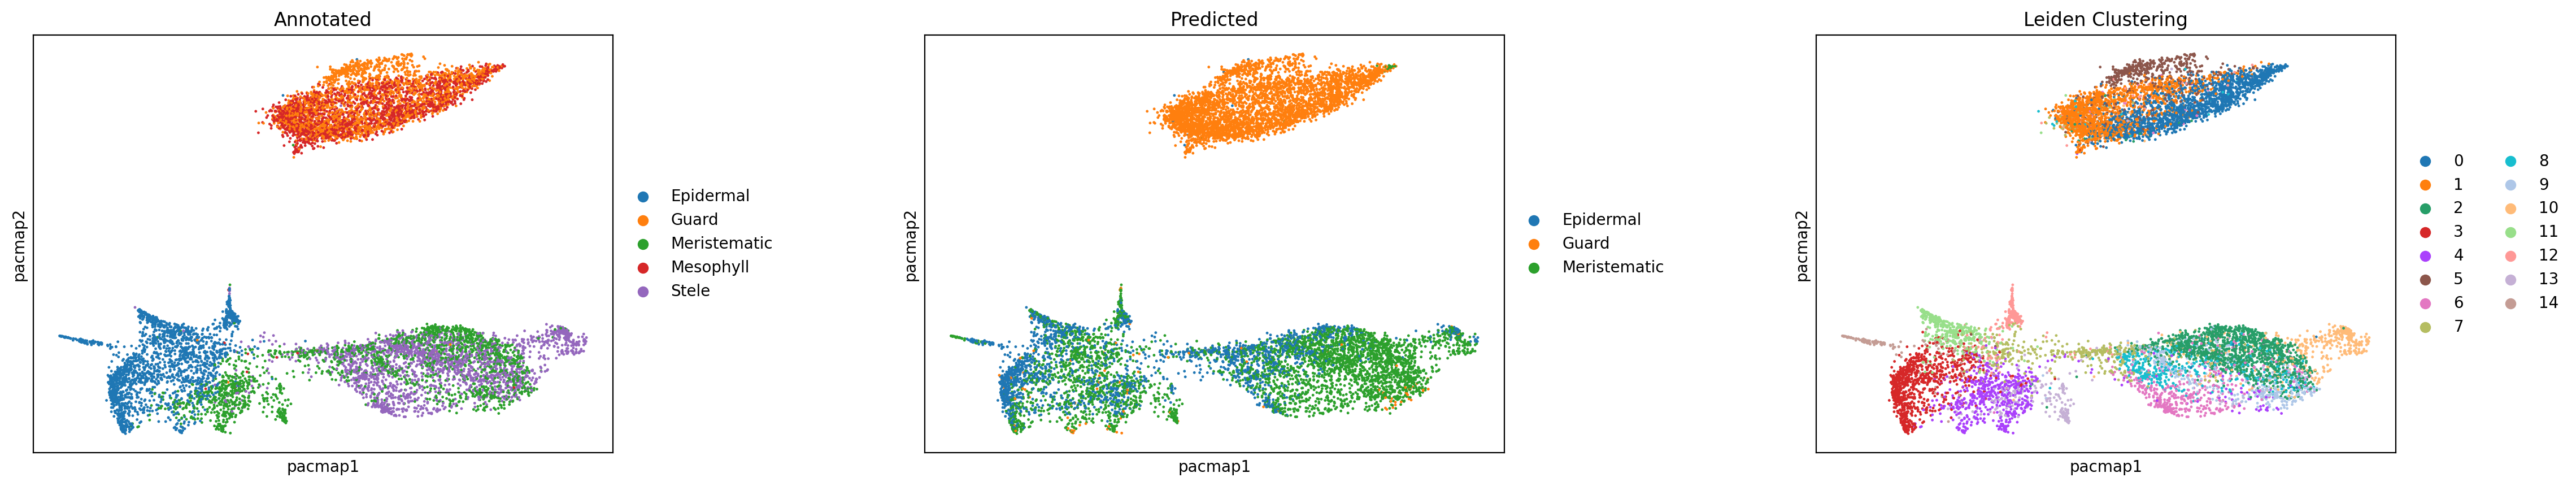

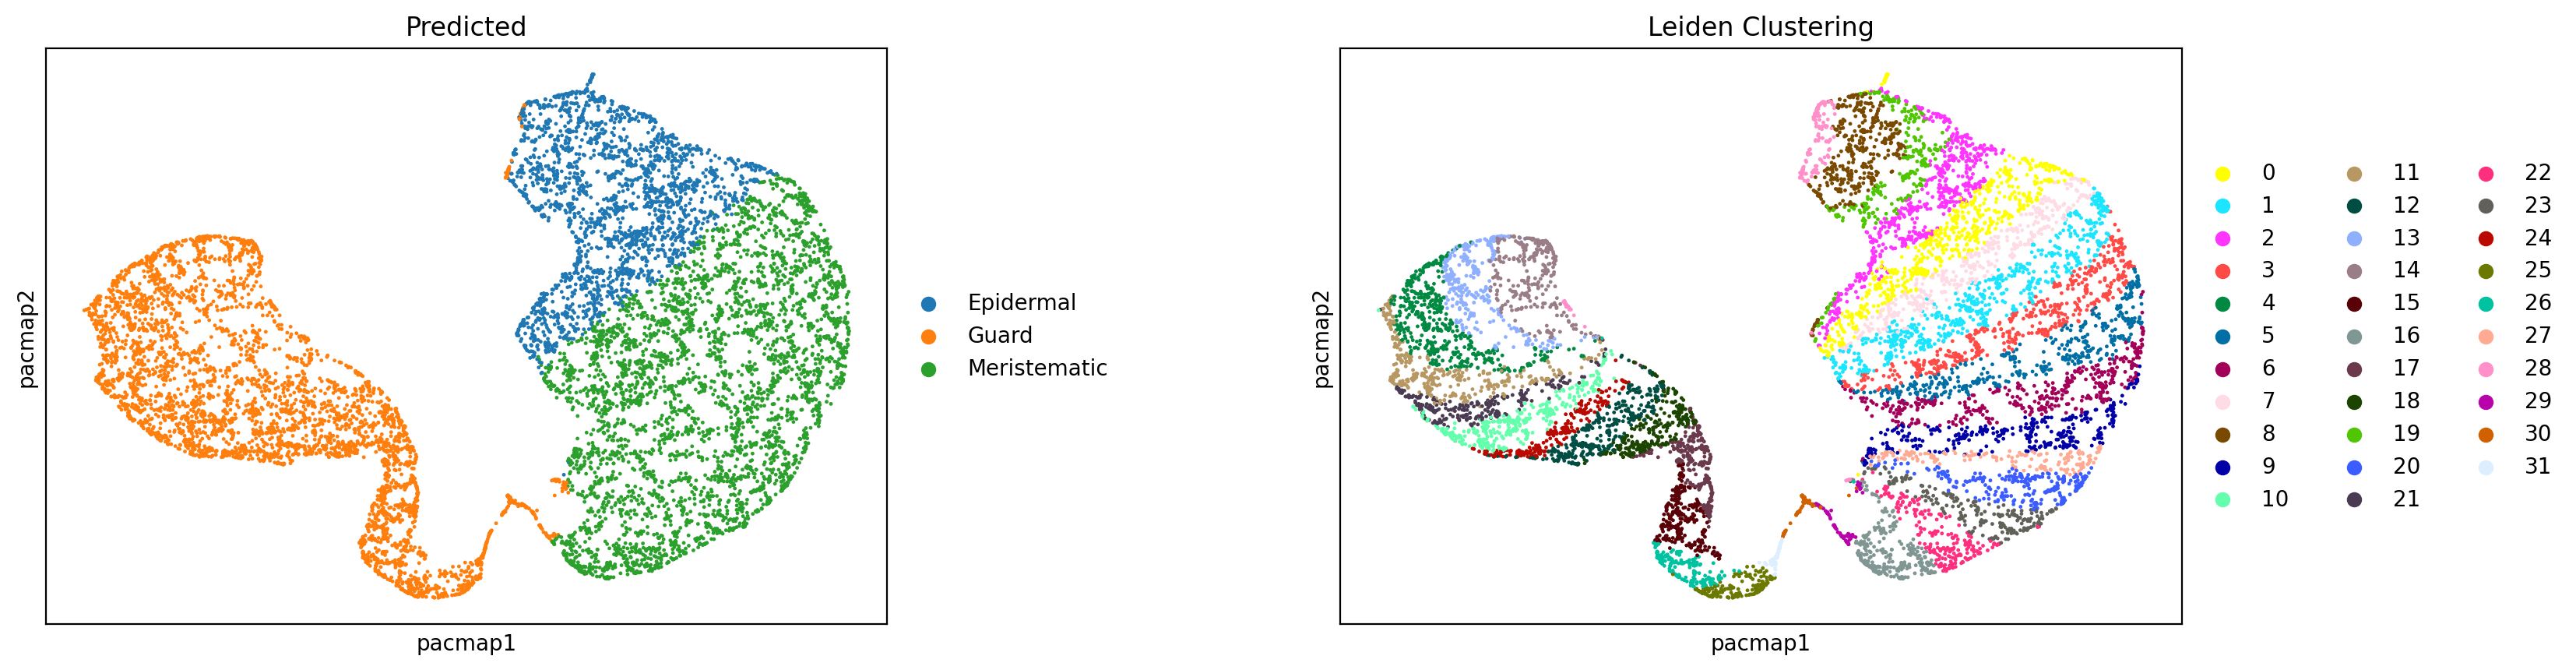

In [11]:
pacmap_plot(true_features, pred_features, g_embs, y_true_text, ys_pred_text)

---